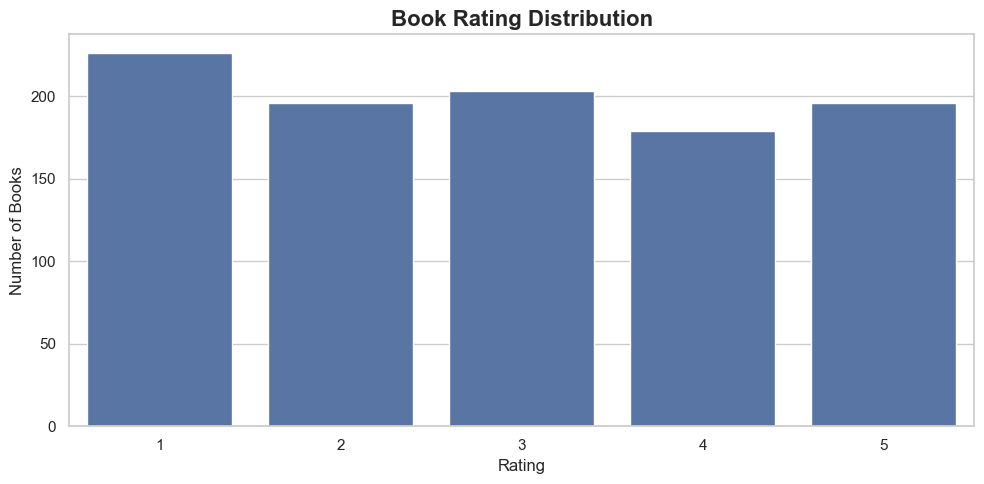

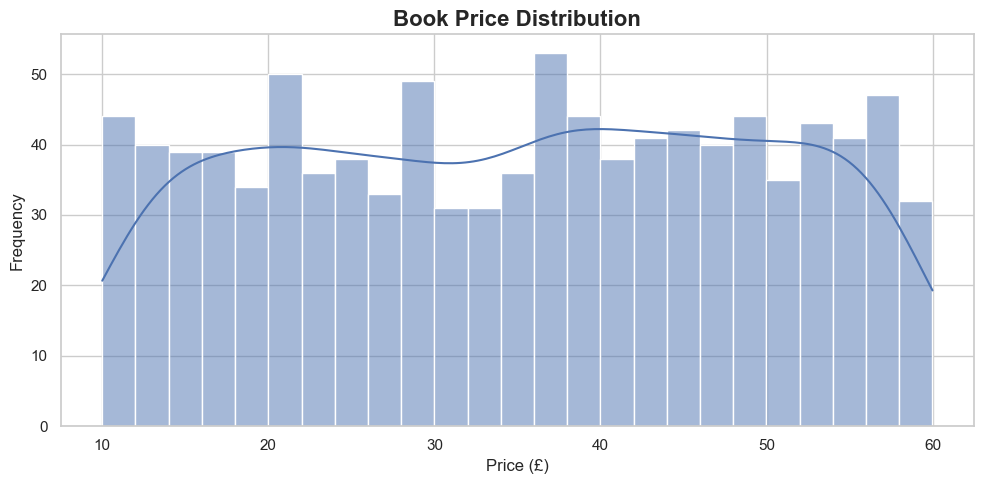

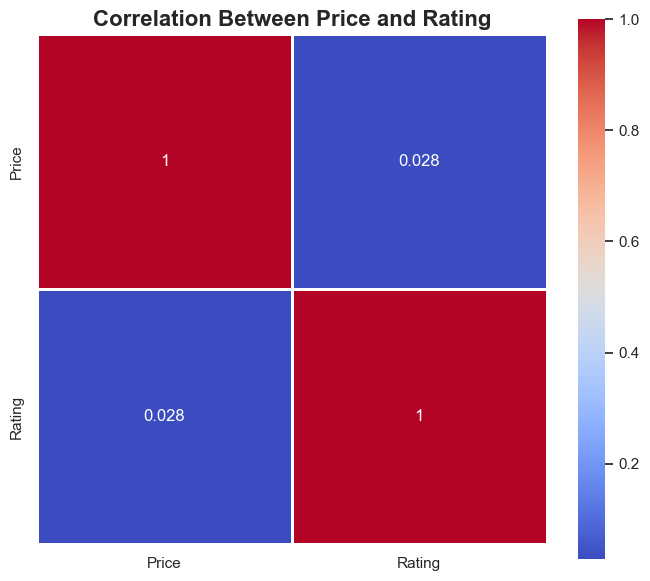

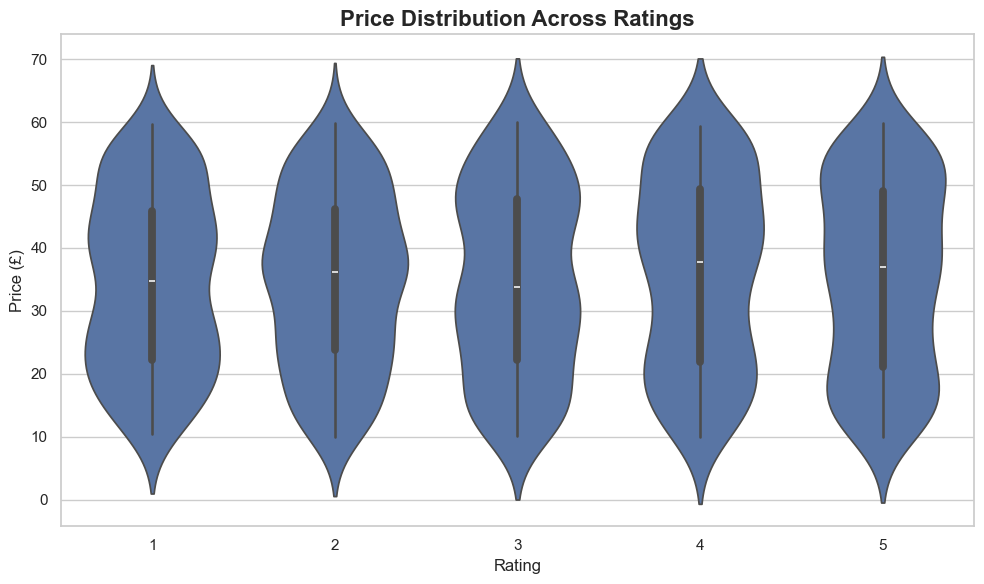

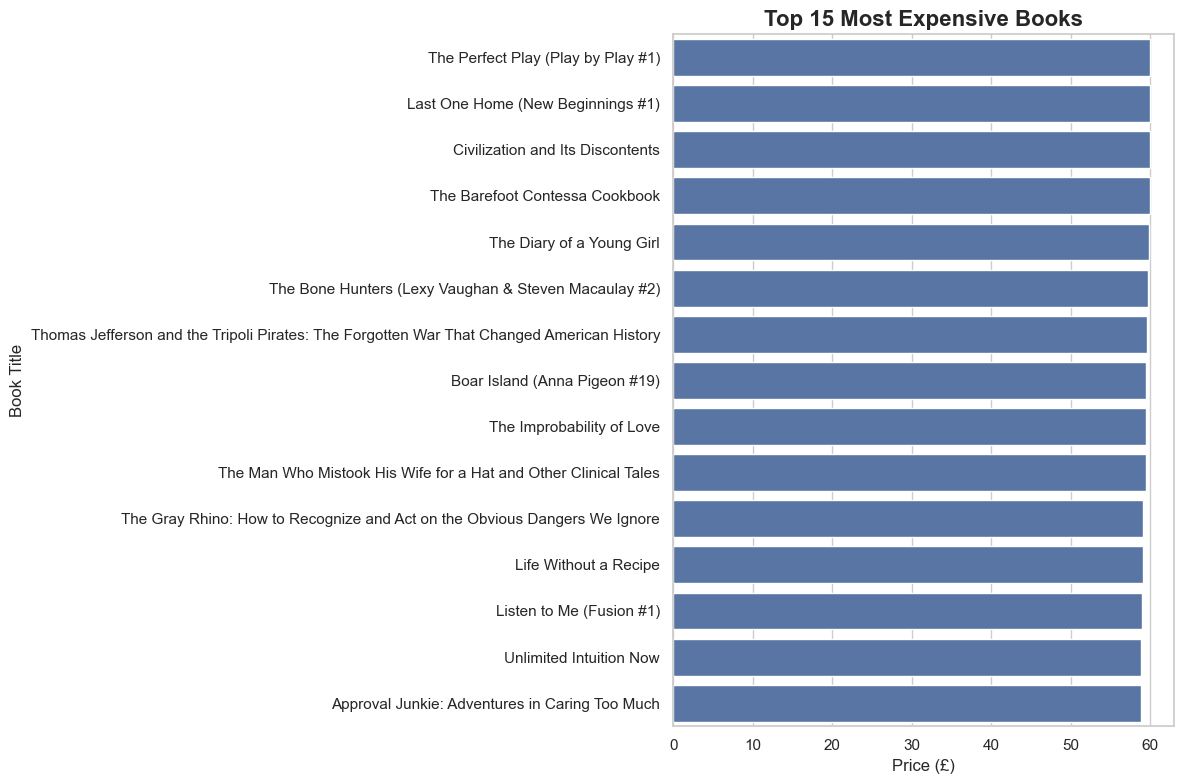

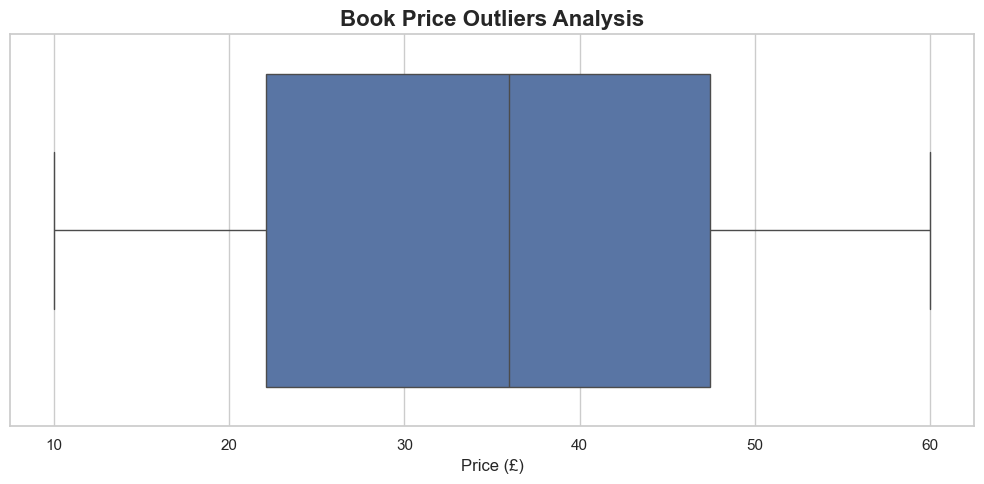

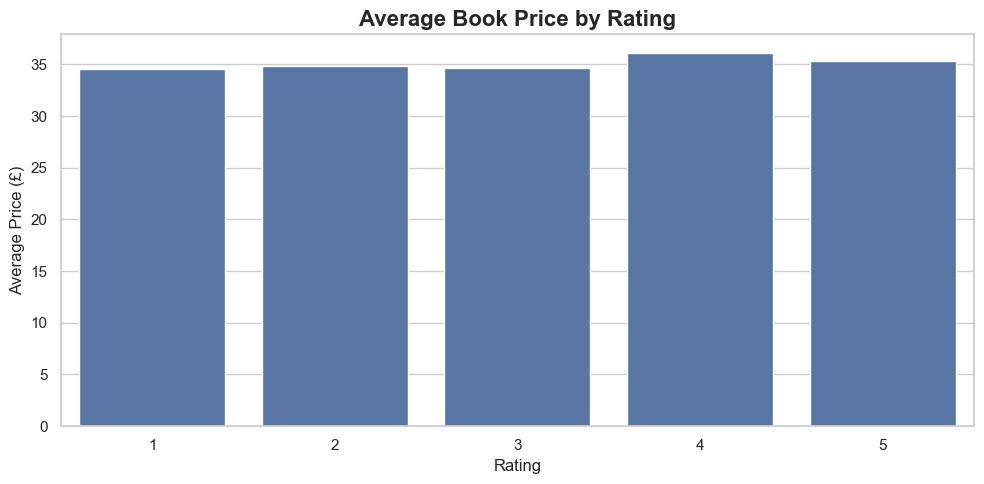


========== DATASET SUMMARY ==========

Total Books: 1000

Average Price: £35.07
Highest Price: £59.99
Lowest Price: £10.00

Rating Distribution:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

Missing Values:
Title     0
Price     0
Rating    0
dtype: int64

Correlation Matrix:
           Price    Rating
Price   1.000000  0.028166
Rating  0.028166  1.000000


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# Load Dataset
# =====================================
df = pd.read_csv('../datasets/books.csv')

# Ensure Correct Data Types
df['Price'] = df['Price'].astype(float)
df['Rating'] = df['Rating'].astype(int)

# Better Visualization Style
sns.set_style("whitegrid")

# =====================================
# CHART 1: Rating Distribution
# =====================================
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Rating'
)

plt.title('Book Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Books')

plt.tight_layout()
plt.show()

# =====================================
# CHART 2: Price Distribution
# =====================================
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Price',
    bins=25,
    kde=True
)

plt.title('Book Price Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# =====================================
# CHART 3: Correlation Heatmap
# =====================================
plt.figure(figsize=(7, 6))

corr = df[['Price', 'Rating']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    square=True
)

plt.title(
    'Correlation Between Price and Rating',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# =====================================
# CHART 4: Price vs Rating (Violin Plot)
# =====================================
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Rating',
    y='Price'
)

plt.title(
    'Price Distribution Across Ratings',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Price (£)')

plt.tight_layout()
plt.show()

# =====================================
# CHART 5: Top 15 Most Expensive Books
# =====================================
top_expensive = df.nlargest(15, 'Price')

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_expensive,
    x='Price',
    y='Title'
)

plt.title(
    'Top 15 Most Expensive Books',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Price (£)')
plt.ylabel('Book Title')

plt.tight_layout()
plt.show()

# =====================================
# CHART 6: Price Outliers Analysis
# =====================================
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Price'
)

plt.title(
    'Book Price Outliers Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Price (£)')

plt.tight_layout()
plt.show()

# =====================================
# CHART 7: Average Price by Rating
# =====================================
avg_price = (
    df.groupby('Rating')['Price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=avg_price,
    x='Rating',
    y='Price'
)

plt.title(
    'Average Book Price by Rating',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Average Price (£)')

plt.tight_layout()
plt.show()

# =====================================
# DATASET SUMMARY
# =====================================
print("\n========== DATASET SUMMARY ==========")

print(f"\nTotal Books: {len(df)}")

print(f"\nAverage Price: £{df['Price'].mean():.2f}")
print(f"Highest Price: £{df['Price'].max():.2f}")
print(f"Lowest Price: £{df['Price'].min():.2f}")

print("\nRating Distribution:")
print(df['Rating'].value_counts().sort_index())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCorrelation Matrix:")
print(df[['Price', 'Rating']].corr())